In [1]:
import mne

raw = mne.io.read_raw_edf('data\physionet_data\S001\S001R03.edf', preload=True, verbose=False)
raw.filter(l_freq=8, h_freq=30, verbose=False)

<RawEDF | S001R03.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [2]:
def get_class_from_time(time_s, annotations):
    for ann in annotations:
        if ann['description'] in ['T1', 'T2']:
            start_time, end_time = ann['onset'], ann['onset'] + ann['duration']
            if start_time <= time_s < end_time: return ann['description']
    return 'T0'

Annotations (time in seconds, duration, description):
0.00s - 4.2s: T0
4.20s - 4.1s: T2
8.30s - 4.2s: T0
12.50s - 4.1s: T1
16.60s - 4.2s: T0
20.80s - 4.1s: T1
24.90s - 4.2s: T0
29.10s - 4.1s: T2
33.20s - 4.2s: T0
37.40s - 4.1s: T2
41.50s - 4.2s: T0
45.70s - 4.1s: T1
49.80s - 4.2s: T0
54.00s - 4.1s: T1
58.10s - 4.2s: T0
62.30s - 4.1s: T2
66.40s - 4.2s: T0
70.60s - 4.1s: T1
74.70s - 4.2s: T0
78.90s - 4.1s: T2
83.00s - 4.2s: T0
87.20s - 4.1s: T2
91.30s - 4.2s: T0
95.50s - 4.1s: T1
99.60s - 4.2s: T0
103.80s - 4.1s: T1
107.90s - 4.2s: T0
112.10s - 4.1s: T2
116.20s - 4.2s: T0
120.40s - 4.1s: T1


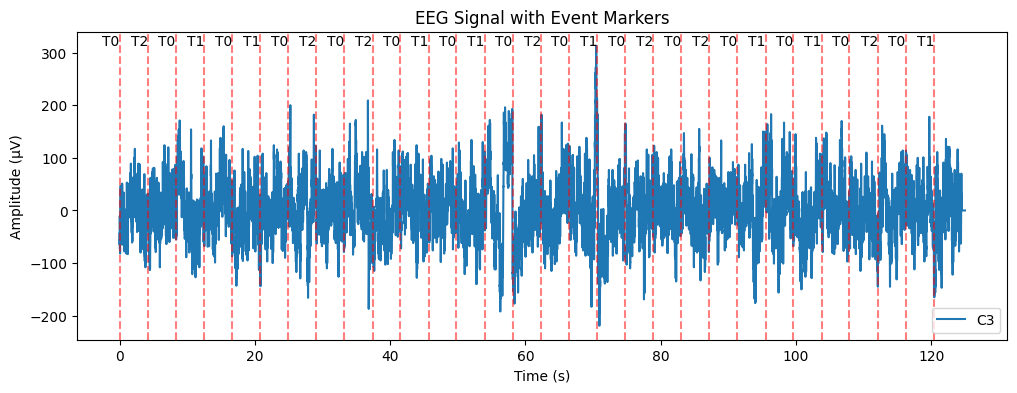

In [5]:
from pyedflib import EdfReader
import numpy as np
import matplotlib.pyplot as plt

# Open the EDF file
file_path = "data\physionet_data\S001\S001R03.edf"
reader = EdfReader(file_path)

# Get signal data and headers
n_channels = reader.signals_in_file
signal_labels = reader.getSignalLabels()
fs = reader.getSampleFrequency(0)  # Assumes all channels have same sample rate
signals = np.array([reader.readSignal(i) for i in range(n_channels)])

# Get annotations (events/timestamps)
annotations = reader.readAnnotations()

# Close the file
reader.close()

# Print annotations
print("Annotations (time in seconds, duration, description):")
for onset, duration, description in zip(annotations[0], annotations[1], annotations[2]):
    print(f"{onset:.2f}s - {duration}s: {description}")

c3_idx = signal_labels.index('C3..')
c3_signal = signals[c3_idx]
time = np.arange(len(c3_signal)) / fs

plt.figure(figsize=(12, 4))
plt.plot(time, c3_signal, label='C3')
for onset, _, desc in zip(annotations[0], annotations[1], annotations[2]):
    plt.axvline(onset, color='red', linestyle='--', alpha=0.5)
    plt.text(onset, np.max(c3_signal), desc, ha='right')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.title('EEG Signal with Event Markers')
plt.legend()
plt.show()

In [25]:
# Script completo para verificação

import mne

# Definição da função
def get_class_from_time(time_s, annotations):
    for ann in annotations:
        if ann['description'] in ['T1', 'T2']:
            start_time = ann['onset']
            end_time = start_time + ann['duration']
            if start_time <= time_s < end_time:
                return ann['description']
    return 'T0'

# Carregamento do arquivo e suas anotações
nome_do_arquivo = r'data/physionet_data/S001/S001R03.edf'
try:
    raw = mne.io.read_raw_edf(nome_do_arquivo, preload=True, verbose=False)
except FileNotFoundError:
    print(f"Erro: Arquivo não encontrado em '{nome_do_arquivo}'. Verifique o caminho.")
    exit()

print("--- Gabarito: Anotações do Arquivo S001R03.edf ---")
print(raw.annotations)
print("-" * 50)
print("\n--- Iniciando Testes na Função get_class_from_time ---")

# Lista de pontos de tempo que queremos testar
test_times = [
    16.5
]

# Executa o teste para cada tempo
for time in test_times:
    classe_encontrada = get_class_from_time(time, raw.annotations)
    print(f"- Para o tempo {time:.2f}s, a classe encontrada é: \t{classe_encontrada}")

--- Gabarito: Anotações do Arquivo S001R03.edf ---
<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>
--------------------------------------------------

--- Iniciando Testes na Função get_class_from_time ---
- Para o tempo 16.50s, a classe encontrada é: 	T1
